In [1]:
# import time
# import pandas as pd
# import requests
# from bs4 import BeautifulSoup

# # Base URL with your requested frequency filters
# BASE_URL = (
#     "https://pswsnetwork.eng.ua.edu/observations/observation_list/"
#     "?centerFrequency=3.330&centerFrequency=7.850&centerFrequency=14.670"
#     "&station=&startDate__gte=&endDate__lte="
#     "&latitude_min=&latitude_max=&longitude_min=&longitude_max="
# )

# headers = {
#     "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
# }


# def scrape_psws_data(max_pages=5):
#     """Scrapes multiple pages of observations from the PSWS network and returns a pandas DataFrame."""
#     all_dataframes = []
#     current_page = 1

#     while current_page <= max_pages:
#         print(f"Scraping page {current_page}...")

#         # Append the page parameter to the URL
#         url = f"{BASE_URL}&page={current_page}"

#         try:
#             response = requests.get(url, headers=headers, timeout=10)

#             # If the page doesn't exist or errors out, stop the loop
#             if response.status_code != 200:
#                 print(f"Stopped at page {current_page} (Status code: {response.status_code})")
#                 break

#             # Use pandas to quickly read the HTML tables on the page
#             tables = pd.read_html(response.text)

#             if tables:
#                 # Assuming the first table on the page contains the observations
#                 df_page = tables[0]

#                 # Drop rows that might just be pagination text or completely empty
#                 df_page = df_page.dropna(how="all")

#                 if not df_page.empty:
#                     all_dataframes.append(df_page)
#                 else:
#                     print("Found an empty table. Ending scrape.")
#                     break
#             else:
#                 print("No tables found on this page. Ending scrape.")
#                 break

#             # Check if there is a 'Next' page link in the HTML to avoid infinite loops
#             soup = BeautifulSoup(response.text, "html.parser")
#             next_button = soup.find("a", string="Next")
#             # Some pagination systems use HTML arrows like '»' or classes like 'next'
#             if not next_button and not soup.search_text("Next"):
#                 # Double checking via broad text search if string matching misses it
#                 if not any(
#                     "next" in a.get("class", [])
#                     for a in soup.find_all("a")
#                 ):
#                     pass  # Keep going unless you explicitly want strict button checking

#             current_page += 1

#             # Be a polite scraper! Pause for 1 second between pages
#             time.sleep(1.0)

#         except Exception as e:
#             print(f"An error occurred on page {current_page}: {e}")
#             break

#     # Combine all individual page dataframes into one master dataframe
#     if all_dataframes:
#         master_df = pd.concat(all_dataframes, ignore_index=True)
#         return master_df
#     else:
#         return pd.DataFrame()


# # Execute the scraper (Adjust max_pages as needed)
# df_observations = scrape_psws_data(max_pages=5)

# # View the results
# print(f"\nSuccessfully collected {len(df_observations)} rows!")
# print(df_observations.head())

# # Optional: Save it to a CSV file
# # df_observations.to_csv("psws_observations.csv", index=False)

Scraping page 1...


/tmp/ipykernel_1132/1057934825.py:39: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


An error occurred on page 1: 'NoneType' object is not callable

Successfully collected 8 rows!
   Data rate                                   Center Frequency  \
0         10                                         14.670 MHz   
1         10                    5.000 MHz, 2.500 MHz, 3.330 MHz   
2         10  10.000 MHz, 5.000 MHz, 2.500 MHz, 15.000 MHz, ...   
3         10  10.000 MHz, 5.000 MHz, 2.500 MHz, 15.000 MHz, ...   
4         10  10.000 MHz, 5.000 MHz, 15.000 MHz, 20.000 MHz,...   

              Station     Instrument  Size (MB)     File/Observation Plot  \
0  pa0rwt Grape-1 DRF      Flex-1500    34.1753  OBS2026-05-21T00-00    🟢   
1               N4RVE          RX888     4.8713  OBS2026-05-21T00-00    🟢   
2               W1EUJ  RX888_Palomar     4.5650  OBS2026-05-21T00-00    🟢   
3              KFS_NW       NW RX888     8.2153  OBS2026-05-21T00-00    🟢   
4             AC0G_ND       RX888_ND    30.5451  OBS2026-05-21T00-00    🟢   

           Start (UTC)            End (

In [2]:
df_observations

,Data rate,Center Frequency,Station,Instrument,Size (MB),File/Observation,Plot,Start (UTC),End (UTC)
0,10,14.670 MHz,pa0rwt Grape-1 DRF,Flex-1500,34.1753,OBS2026-05-21T00-00,🟢,2026-05-21 00:00:00,2026-05-22 00:00:00
1,10,"5.000 MHz, 2.500 MHz, 3.330 MHz",N4RVE,RX888,4.8713,OBS2026-05-21T00-00,🟢,2026-05-21 00:00:00,2026-05-21 23:59:00
2,10,"10.000 MHz, 5.000 MHz, 2.500 MHz, 15.000 MHz, ...",W1EUJ,RX888_Palomar,4.5650,OBS2026-05-21T00-00,🟢,2026-05-21 00:00:00,2026-05-21 23:59:00
3,10,"10.000 MHz, 5.000 MHz, 2.500 MHz, 15.000 MHz, ...",KFS_NW,NW RX888,8.2153,OBS2026-05-21T00-00,🟢,2026-05-21 00:00:00,2026-05-21 23:59:00
4,10,"10.000 MHz, 5.000 MHz, 15.000 MHz, 20.000 MHz,...",AC0G_ND,RX888_ND,30.5451,OBS2026-05-21T00-00,🟢,2026-05-21 00:00:00,2026-05-21 23:59:00
5,10,"10.000 MHz, 5.000 MHz, 2.500 MHz, 15.000 MHz, ...",K9TRV RX888-1,RX888,27.8936,OBS2026-05-21T00-00,🟢,2026-05-21 00:00:00,2026-05-21 23:59:00
6,10,"10.000 MHz, 5.000 MHz, 2.500 MHz, 15.000 MHz, ...",AC0G_B2,RX888-ka9q,15.3501,OBS2026-05-21T00-00,🟢,2026-05-21 00:00:00,2026-05-21 23:59:00
7,10,"10.000 MHz, 5.000 MHz, 2.500 MHz, 15.000 MHz, ...",WA2TP-2,RX888#1,35.4846,OBS2026-05-21T00-00,🟢,2026-05-21 00:00:00,2026-05-21 23:59:00


In [ ]:
import time
import pandas as pd
import requests
from bs4 import BeautifulSoup

# Base URL with your exact requested filters
BASE_URL = (
    "https://pswsnetwork.eng.ua.edu/observations/observation_list/"
    "?centerFrequency=3.330&centerFrequency=7.850&centerFrequency=14.670"
    "&station=&startDate__gte=&endDate__lte="
    "&latitude_min=&latitude_max=&longitude_min=&longitude_max="
)

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}


def scrape_psws_inventory(max_pages=5):
    """Scrapes multi-page inventory tables from the PSWS server using target pagination blocks."""
    all_dataframes = []
    current_page = 1

    while current_page <= max_pages:
        print(f"Scraping page {current_page}...")

        # Construct current page target URL
        url = f"{BASE_URL}&page={current_page}"

        try:
            response = requests.get(url, headers=headers, timeout=12)

            if response.status_code != 200:
                print(f"Reached boundary or error at page {current_page} (Status: {response.status_code})")
                break

            # 1. Parse table with Pandas
            tables = pd.read_html(response.text)
            if not tables:
                print("No HTML tables found on this page. Stopping.")
                break

            df_page = tables[0]
            df_page = df_page.dropna(how="all")

            if not df_page.empty:
                all_dataframes.append(df_page)
            else:
                print("Found an empty table section. Stopping.")
                break

            # 2. Inspect the Bootstrap pagination structure sent by the server
            soup = BeautifulSoup(response.text, "html.parser")
            pagination_ul = soup.find("ul", class_="pagination")

            if not pagination_ul:
                print("No pagination elements discovered. Single-page dataset.")
                break

            # Extract all numeric page references present in the pagination block
            available_pages = []
            for link in pagination_ul.find_all("a"):
                href = link.get("href", "")
                if "page=" in href:
                    try:
                        # Extract the integer digit right after 'page='
                        p_num = int(href.split("page=")[-1])
                        available_pages.append(p_num)
                    except ValueError:
                        continue

            # If our next target page is higher than anything listed in the pagination grid, wrap up
            if available_pages and (current_page + 1) > max(available_pages):
                print(f"Successfully reached the final page listed ({current_page}).")
                break

            current_page += 1
            time.sleep(1.2)  # Generous safety sleep for courteous indexing

        except Exception as e:
            print(f"An unexpected interruption occurred on page {current_page}: {e}")
            break

    # Consolidate results
    if all_dataframes:
        master_inventory_df = pd.concat(all_dataframes, ignore_index=True)
        return master_inventory_df
    else:
        return pd.DataFrame()


# Execute Scraper
# Note: Increase max_pages to catch the full inventory length as desired!
df_inventory = scrape_psws_inventory(max_pages=5000)

print(f"\nInventory Build Complete! Gathered {len(df_inventory)} total observation records.")
if not df_inventory.empty:
    print(df_inventory[["Center Frequency", "Station", "Instrument", "Start (UTC)"]].head())

In [20]:
df_inventory.shape

df_inventory.to_csv('CHU Data Inventory.csv')

In [22]:
df = df_inventory.copy()
df.head(3)

,Data rate,Center Frequency,Station,Instrument,Size (MB),File/Observation,Plot,Start (UTC),End (UTC)
0,10,14.670 MHz,pa0rwt Grape-1 DRF,Flex-1500,34.1753,OBS2026-05-21T00-00,🟢,2026-05-21 00:00:00,2026-05-22 00:00:00
1,10,"5.000 MHz, 2.500 MHz, 3.330 MHz",N4RVE,RX888,4.8713,OBS2026-05-21T00-00,🟢,2026-05-21 00:00:00,2026-05-21 23:59:00
2,10,"10.000 MHz, 5.000 MHz, 2.500 MHz, 15.000 MHz, ...",W1EUJ,RX888_Palomar,4.5650,OBS2026-05-21T00-00,🟢,2026-05-21 00:00:00,2026-05-21 23:59:00


In [31]:
import time
import pandas as pd
import requests
from bs4 import BeautifulSoup

BASE_URL = (
    "https://pswsnetwork.eng.ua.edu/observations/observation_list/"
    "?centerFrequency=3.330&centerFrequency=7.850&centerFrequency=14.670"
    "&station=&startDate__gte=&endDate__lte="
    "&latitude_min=&latitude_max=&longitude_min=&longitude_max="
)

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}


def build_inventory_with_links(max_pages=30000):
    """Scrapes the HTML table and parses out the actual download links for each observation."""
    all_rows = []
    current_page = 1

    while current_page <= max_pages:
        print(f"Indexing metadata from page {current_page}...")
        url = f"{BASE_URL}&page={current_page}"

        try:
            response = requests.get(url, headers=headers, timeout=12)
            if response.status_code != 200:
                break

            soup = BeautifulSoup(response.text, "html.parser")
            table = soup.find("table", class_="obsTable")

            if not table:
                print("Table not found. Ending.")
                break

            # Find all data rows inside the table body
            tbody = table.find("tbody")
            if not tbody:
                break

            for tr in tbody.find_all("tr"):
                tds = tr.find_all("td")
                if len(tds) < 9:  # Safeguard for unexpected row shapes
                    continue

                # Safely extract text from the standard table cells
                data_rate = tds[0].get_text(strip=True)
                freqs = tds[1].get_text(strip=True)
                station = tds[2].get_text(strip=True)
                instrument = tds[3].get_text(strip=True)
                size_mb = tds[4].get_text(strip=True)
                file_text = tds[5].get_text(strip=True)
                start_utc = tds[7].get_text(strip=True)
                end_utc = tds[8].get_text(strip=True)

                # --- THE MAGIC STEP ---
                # Look inside the File/Observation cell (tds[5]) for the actual link
                file_link_tag = tds[5].find("a")
                download_url = ""
                obs_id = ""

                if file_link_tag and "href" in file_link_tag.attrs:
                    relative_path = file_link_tag["href"]  # e.g., "/observations/select_download_range/167207/"
                    download_url = f"https://pswsnetwork.eng.ua.edu{relative_path}"

                    # Clean extract the unique Observation ID from the path strings
                    path_parts = [p for p in relative_path.split("/") if p]
                    if path_parts:
                        obs_id = path_parts[-1]

                # Append everything cleanly into our master data collector
                all_rows.append(
                    {
                        "Observation_ID": obs_id,
                        "Station": station,
                        "Instrument": instrument,
                        "Center_Frequencies": freqs,
                        "Size_MB": size_mb,
                        "File_Label": file_text,
                        "Start_UTC": start_utc,
                        "End_UTC": end_utc,
                        "Direct_Download_URL": download_url,
                    }
                )

            # Pagination boundary check
            pagination_ul = soup.find("ul", class_="pagination")
            if pagination_ul:
                available_pages = [
                    int(a["href"].split("page=")[-1])
                    for a in pagination_ul.find_all("a")
                    if "page=" in a.get("href", "")
                ]
                if available_pages and (current_page + 1) > max(available_pages):
                    print("Reached final page listing.")
                    break

            current_page += 1
            time.sleep(1.0)

        except Exception as e:
            print(f"Error on page {current_page}: {e}")
            break

    return pd.DataFrame(all_rows)


# Run it!
df_inventory = build_inventory_with_links(max_pages=20)
print(f"\nInventory built with {len(df_inventory)} items!")

# Let's inspect our new dataframe columns, including the hidden download links!
print(df_inventory[["Station", "Observation_ID", "Direct_Download_URL"]].head())

Indexing metadata from page 1...
Indexing metadata from page 2...
Indexing metadata from page 3...
Indexing metadata from page 4...
Indexing metadata from page 5...
Indexing metadata from page 6...
Indexing metadata from page 7...
Indexing metadata from page 8...
Indexing metadata from page 9...
Indexing metadata from page 10...
Indexing metadata from page 11...
Indexing metadata from page 12...
Indexing metadata from page 13...
Indexing metadata from page 14...
Indexing metadata from page 15...
Indexing metadata from page 16...
Indexing metadata from page 17...
Indexing metadata from page 18...
Indexing metadata from page 19...
Indexing metadata from page 20...

Inventory built with 160 items!
              Station Observation_ID  \
0  pa0rwt Grape-1 DRF         167207   
1               N4RVE         167209   
2               W1EUJ         167219   
3              KFS_NW         167220   
4             AC0G_ND         167225   

                                 Direct_Download_URL  


In [24]:
# To download a specific row later:
file_response = requests.get(df_inventory.loc[0, "Direct_Download_URL"], headers=headers)
with open(f"{df_inventory.loc[0, 'File_Label']}.zip", "wb") as f:
    f.write(file_response.content)

In [25]:
df_inventory.head(3)


,Observation_ID,Station,Instrument,Center_Frequencies,Size_MB,File_Label,Start_UTC,End_UTC,Direct_Download_URL
0,167207,pa0rwt Grape-1 DRF,Flex-1500,14.670 MHz,34.1753,OBS2026-05-21T00-00,2026-05-21 00:00:00,2026-05-22 00:00:00,https://pswsnetwork.eng.ua.edu/observations/se...
1,167209,N4RVE,RX888,"5.000 MHz, 2.500 MHz, 3.330 MHz",4.8713,OBS2026-05-21T00-00,2026-05-21 00:00:00,2026-05-21 23:59:00,https://pswsnetwork.eng.ua.edu/observations/se...
2,167219,W1EUJ,RX888_Palomar,"10.000 MHz, 5.000 MHz, 2.500 MHz, 15.000 MHz, ...",4.5650,OBS2026-05-21T00-00,2026-05-21 00:00:00,2026-05-21 23:59:00,https://pswsnetwork.eng.ua.edu/observations/se...
3,167220,KFS_NW,NW RX888,"10.000 MHz, 5.000 MHz, 2.500 MHz, 15.000 MHz, ...",8.2153,OBS2026-05-21T00-00,2026-05-21 00:00:00,2026-05-21 23:59:00,https://pswsnetwork.eng.ua.edu/observations/se...
4,167225,AC0G_ND,RX888_ND,"10.000 MHz, 5.000 MHz, 15.000 MHz, 20.000 MHz,...",30.5451,OBS2026-05-21T00-00,2026-05-21 00:00:00,2026-05-21 23:59:00,https://pswsnetwork.eng.ua.edu/observations/se...
5,167226,K9TRV RX888-1,RX888,"10.000 MHz, 5.000 MHz, 2.500 MHz, 15.000 MHz, ...",27.8936,OBS2026-05-21T00-00,2026-05-21 00:00:00,2026-05-21 23:59:00,https://pswsnetwork.eng.ua.edu/observations/se...
6,167228,AC0G_B2,RX888-ka9q,"10.000 MHz, 5.000 MHz, 2.500 MHz, 15.000 MHz, ...",15.3501,OBS2026-05-21T00-00,2026-05-21 00:00:00,2026-05-21 23:59:00,https://pswsnetwork.eng.ua.edu/observations/se...
7,167229,WA2TP-2,RX888#1,"10.000 MHz, 5.000 MHz, 2.500 MHz, 15.000 MHz, ...",35.4846,OBS2026-05-21T00-00,2026-05-21 00:00:00,2026-05-21 23:59:00,https://pswsnetwork.eng.ua.edu/observations/se...
8,167230,G4HZX-Loop,RX888,"10.000 MHz, 5.000 MHz, 2.500 MHz, 15.000 MHz, ...",22.7875,OBS2026-05-21T00-00,2026-05-21 00:00:00,2026-05-21 23:59:00,https://pswsnetwork.eng.ua.edu/observations/se...
9,167232,G4HZX-Main,RX888,"10.000 MHz, 5.000 MHz, 2.500 MHz, 15.000 MHz, ...",21.0248,OBS2026-05-21T00-00,2026-05-21 00:00:00,2026-05-21 23:59:00,https://pswsnetwork.eng.ua.edu/observations/se...


In [26]:
df

,Data rate,Center Frequency,Station,Instrument,Size (MB),File/Observation,Plot,Start (UTC),End (UTC)
0,10,14.670 MHz,pa0rwt Grape-1 DRF,Flex-1500,34.1753,OBS2026-05-21T00-00,🟢,2026-05-21 00:00:00,2026-05-22 00:00:00
1,10,"5.000 MHz, 2.500 MHz, 3.330 MHz",N4RVE,RX888,4.8713,OBS2026-05-21T00-00,🟢,2026-05-21 00:00:00,2026-05-21 23:59:00
2,10,"10.000 MHz, 5.000 MHz, 2.500 MHz, 15.000 MHz, ...",W1EUJ,RX888_Palomar,4.5650,OBS2026-05-21T00-00,🟢,2026-05-21 00:00:00,2026-05-21 23:59:00
3,10,"10.000 MHz, 5.000 MHz, 2.500 MHz, 15.000 MHz, ...",KFS_NW,NW RX888,8.2153,OBS2026-05-21T00-00,🟢,2026-05-21 00:00:00,2026-05-21 23:59:00
4,10,"10.000 MHz, 5.000 MHz, 15.000 MHz, 20.000 MHz,...",AC0G_ND,RX888_ND,30.5451,OBS2026-05-21T00-00,🟢,2026-05-21 00:00:00,2026-05-21 23:59:00
...,...,...,...,...,...,...,...,...,...
6523,1,14.670 MHz,pa0rwt Grape-1 Fldigi,Grape 1 Legacy,3.8790,2024-08-31T000000Z_N0000035_C1_JO33lg_FRQ_CHU1...,🟢,2024-08-31 00:00:00,2024-08-31 00:00:00
6524,1,7.850 MHz,W1XP Node 44,Grape 1 Legacy,3.8819,2024-08-31T000000Z_N0000044_G1_FN42fo_FRQ_CHU7...,🟢,2024-08-31 00:00:00,2024-08-31 00:00:00
6525,1,3.330 MHz,N8OBJ Node 1032,Grape 2,3.5448,2024-08-31T000000Z_N0001032_G2R1_EN91fh_FRQ_CH...,🟢,2024-08-31 00:00:00,2024-08-31 00:00:00
6526,1,7.850 MHz,N8OBJ Node 1032,Grape 2,3.5448,2024-08-31T000000Z_N0001032_G2R2_EN91fh_FRQ_CH...,🟢,2024-08-31 00:00:00,2024-08-31 00:00:00


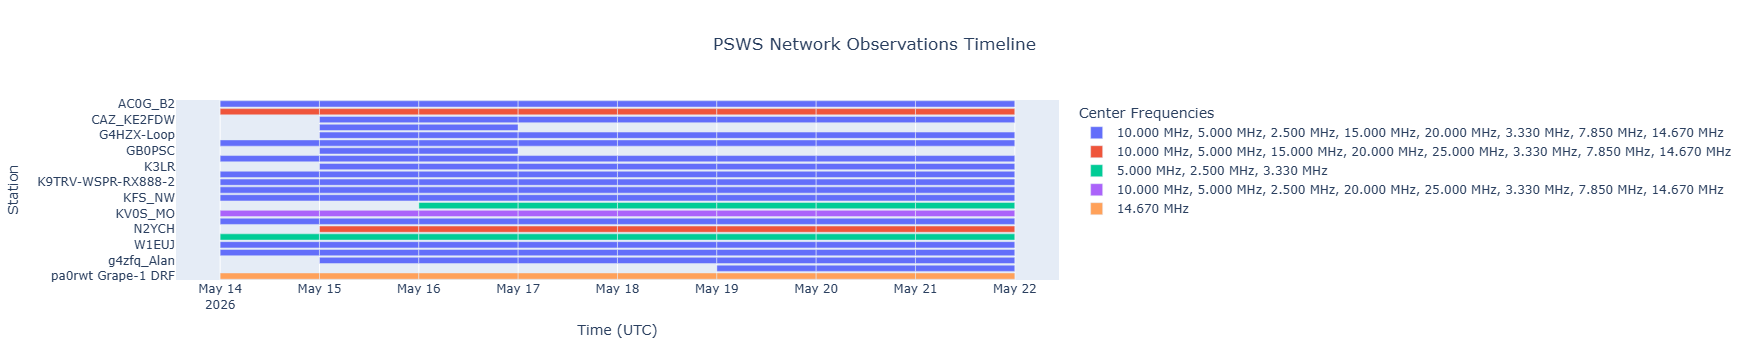

In [33]:
# import pandas as pd
# import plotly.express as px

# # 1. Convert the Start and End columns to datetime objects
# df_inventory["Start_UTC"] = pd.to_datetime(df_inventory["Start_UTC"])
# df_inventory["End_UTC"] = pd.to_datetime(df_inventory["End_UTC"])

# # 2. Sort by Station and Start time so the chart looks organized
# df_inventory = df_inventory.sort_values(by=["Station", "Start_UTC"])

# # 3. Generate the Gantt chart using px.timeline
# fig = px.timeline(
#     df_inventory,
#     x_start="Start_UTC",
#     x_end="End_UTC",
#     y="Station",
#     color="Center_Frequencies",
#     title="PSWS Network Observations Timeline",
#     # Hover data lets you see extra details when you mouse over a bar
#     hover_data={
#         "Instrument": True,
#         "Size_MB": True,
#         "Center_Frequencies": False,  # Redundant since it's the color
#         "Start_UTC": "|%Y-%m-%d %H:%M",  # Format the hover dates cleanly
#         "End_UTC": "|%Y-%m-%d %H:%M",
#     },
# )

# # 4. Clean up the layout
# fig.update_layout(
#     xaxis_title="Time (UTC)",
#     yaxis_title="Station",
#     legend_title="Center Frequencies",
#     # This keeps the bars tight and readable if you have many stations
#     yaxis={"categoryorder": "category descending"},
#     title_x=0.5,  # Center the title
# )

# # Display the interactive chart
# fig.show()

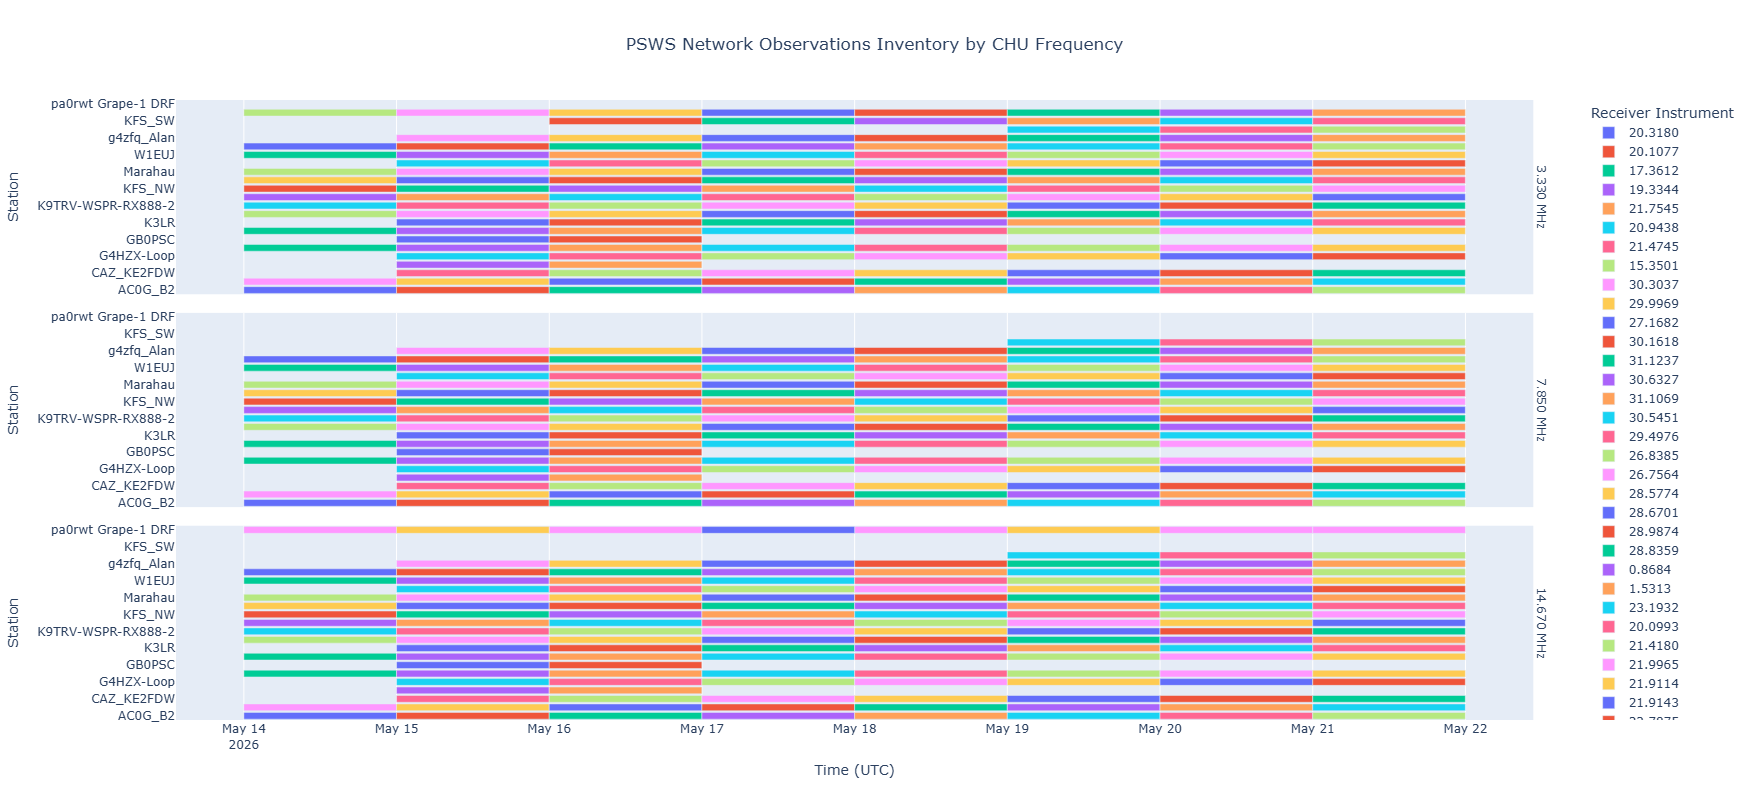

In [38]:
# import pandas as pd
# import plotly.express as px

# # 1. Ensure datetimes are properly parsed
# df_inventory["Start_UTC"] = pd.to_datetime(df_inventory["Start_UTC"])
# df_inventory["End_UTC"] = pd.to_datetime(df_inventory["End_UTC"])

# # 2. Clean and explode the frequencies to isolate CHU channels
# df_faceted = df_inventory.copy()
# df_faceted["Center_Frequencies"] = (
#     df_faceted["Center_Frequencies"]
#     .str.replace(" MHz", "", regex=False)
#     .str.split(", ")
# )
# df_faceted = df_faceted.explode("Center_Frequencies")

# # Filter down strictly to CHU channels
# chu_frequencies = ["3.330", "7.850", "14.670"]
# df_faceted = df_faceted[df_faceted["Center_Frequencies"].isin(chu_frequencies)]

# # Format the frequency name for nicer facet headers (e.g., "3.330 MHz")
# df_faceted["Frequency_Header"] = df_faceted["Center_Frequencies"] + " MHz"

# # 3. Sort so everything aligns beautifully
# df_faceted = df_faceted.sort_values(by=["Frequency_Header", "Station", "Start_UTC"])

# # 4. Generate the Faceted Gantt Chart
# fig = px.timeline(
#     df_faceted,
#     x_start="Start_UTC",
#     x_end="End_UTC",
#     y="Station",
#     color="Instrument",         # this drives the color palette now
#     color_continuous_scale="Viridis",  # "Viridis", "Plasma", or "Cividis" work beautifully here
#     facet_row="Frequency_Header",  # Splits the chart into 3 distinct stacked rows
#     category_orders={"Frequency_Header": ["3.330 MHz", "7.850 MHz", "14.670 MHz"]},
#     title="PSWS Network Observations Inventory by CHU Frequency",
#     hover_data={
#         "Size_MB": True,
#         "Start_UTC": "|%Y-%m-%d %H:%M",
#         "End_UTC": "|%Y-%m-%d %H:%M",
#     },
# )

# # 5. Clean up layout text and layout height
# # Faceted plots need extra height to avoid looking squished
# fig.update_layout(
#     height=800,
#     xaxis_title="Time (UTC)",
#     yaxis_title="Station",
#     legend_title="Receiver Instrument",
#     title_x=0.5,
# )

# # Clean up the automatic row labels on the right side of the subplots
# fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

# fig.show()

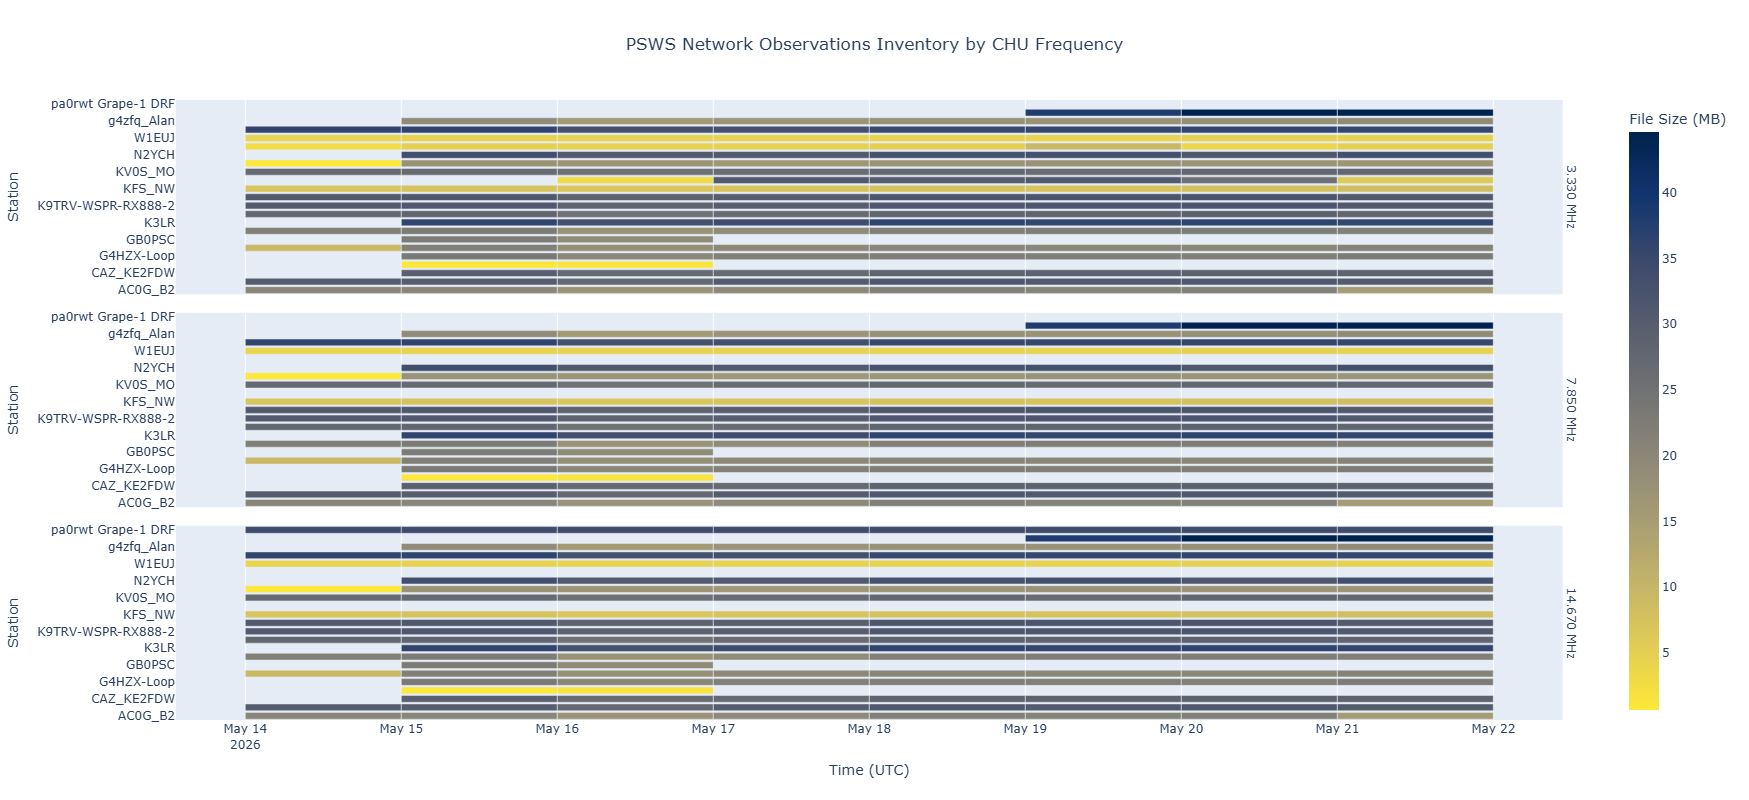

In [43]:
import pandas as pd
import plotly.express as px

# 1. Ensure datetimes are properly parsed
df_inventory["Start_UTC"] = pd.to_datetime(df_inventory["Start_UTC"])
df_inventory["End_UTC"] = pd.to_datetime(df_inventory["End_UTC"])

# 2. Clean and explode frequencies to isolate CHU channels
df_faceted = df_inventory.copy()
df_faceted["Center_Frequencies"] = (
    df_faceted["Center_Frequencies"]
    .str.replace(" MHz", "", regex=False)
    .str.split(", ")
)
df_faceted = df_faceted.explode("Center_Frequencies")

# Filter down strictly to CHU channels
chu_frequencies = ["3.330", "7.850", "14.670"]
df_faceted = df_faceted[df_faceted["Center_Frequencies"].isin(chu_frequencies)]
df_faceted["Frequency_Header"] = df_faceted["Center_Frequencies"] + " MHz"

# --- THE CRITICAL STEP ---
# 3. Convert Size_MB from text string to a float number for continuous mapping
df_faceted["Size_MB"] = pd.to_numeric(df_faceted["Size_MB"], errors="coerce")

# 4. Sort the data
df_faceted = df_faceted.sort_values(by=["Frequency_Header", "Station", "Start_UTC"])

# 5. Generate the Faceted Gantt Chart with Continuous Color
fig = px.timeline(
    df_faceted,
    x_start="Start_UTC",
    x_end="End_UTC",
    y="Station",
    color="Size_MB",               # Continuous mapping triggered by numeric data
    color_continuous_scale="Cividis_r",  # "Viridis", "Plasma", or "Cividis" work beautifully here
    facet_row="Frequency_Header",
    category_orders={"Frequency_Header": ["3.330 MHz", "7.850 MHz", "14.670 MHz"]},
    title="PSWS Network Observations Inventory by CHU Frequency",
    hover_data={
        "Instrument": True,
        "Size_MB": ":.2f",         # Format hover text to two decimal places
        "Start_UTC": "|%Y-%m-%d %H:%M",
        "End_UTC": "|%Y-%m-%d %H:%M",
    },
)

# 6. Layout adjustments
fig.update_layout(
    height=800,
    xaxis_title="Time (UTC)",
    yaxis_title="Station",
    coloraxis_colorbar_title="File Size (MB)",  # Set title of the continuous colorbar
    title_x=0.5,
)

# Clean up the automatic row labels on the right side of the subplots
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

fig.show()

In [36]:
df_inventory.columns

Index(['Observation_ID', 'Station', 'Instrument', 'Center_Frequencies',
       'Size_MB', 'File_Label', 'Start_UTC', 'End_UTC', 'Direct_Download_URL'],
      dtype='object')